In [79]:
import sys
sys.path.append("/content")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from M_lp import MLP
from adaline import Adaline

In [80]:



# ----------------------------------------
# Load Dataset
# ----------------------------------------

dataset = pd.read_csv("/content/iit_h_mess_dataset_5000.csv")

# Separate features and target
features = dataset.drop(columns=["student_id", "mess_duration"]).values
target = dataset["mess_duration"].values.reshape(-1, 1)


# ----------------------------------------
# Feature Normalization
# ----------------------------------------

features = (features - np.mean(features, axis=0)) / np.std(features, axis=0)


# ----------------------------------------
# Set Random Seeds
# ----------------------------------------

np.random.seed(42)
random.seed(42)


# ----------------------------------------
# Shuffle Data
# ----------------------------------------

perm = np.random.permutation(features.shape[0])

split_point = int(0.8 * features.shape[0])

train_indices = perm[:split_point]
val_indices = perm[split_point:]


# ----------------------------------------
# Train / Validation Split
# ----------------------------------------

X_train = features[train_indices]
X_val = features[val_indices]

y_train = target[train_indices]
y_val = target[val_indices]

Running architecture: depth1


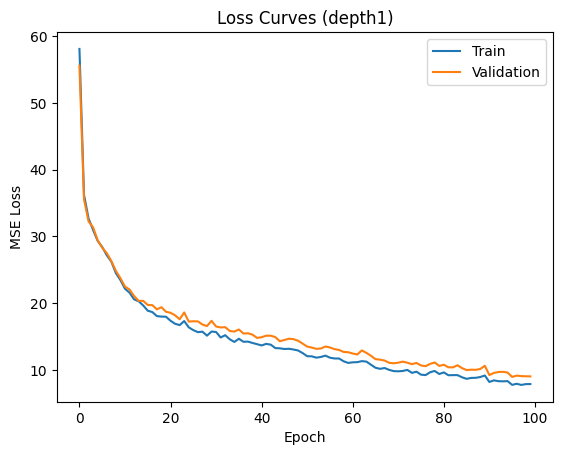

Validation MSE: 9.032205829674698
Average Epoch Time: 0.01917268514633179
Running architecture: depth2


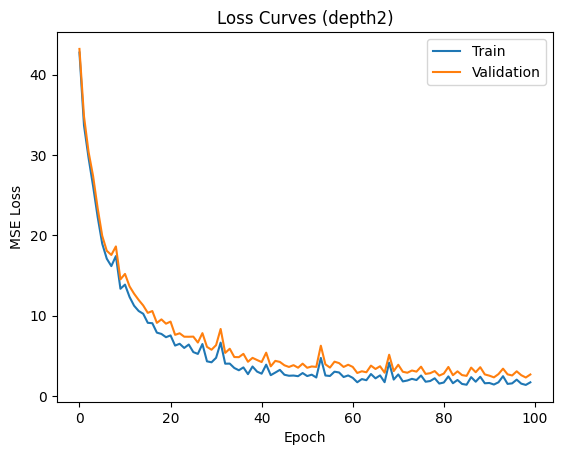

Validation MSE: 2.6742236964182
Average Epoch Time: 0.03472335338592529
Running architecture: depth3


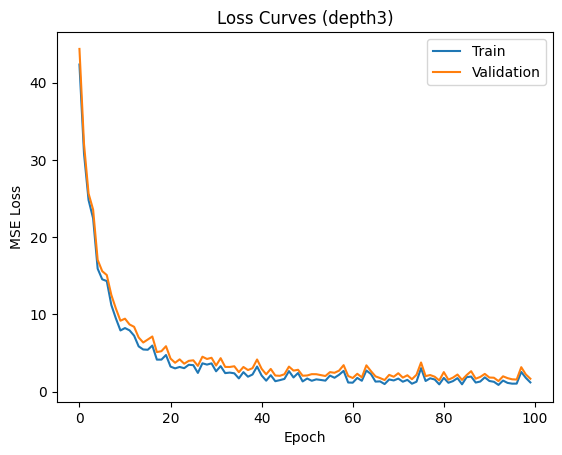

Validation MSE: 1.6659426233874342
Average Epoch Time: 0.05743495941162109
Running architecture: depth4


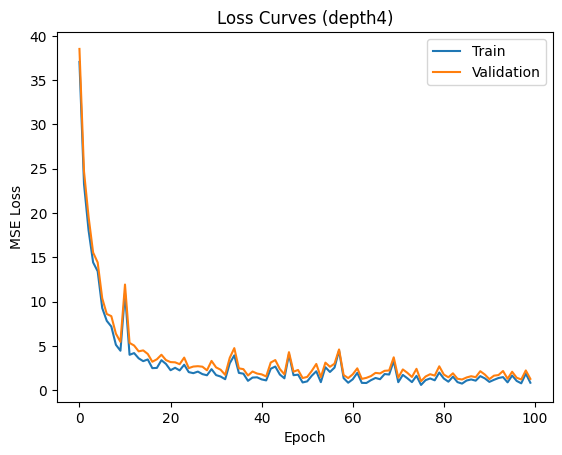

Validation MSE: 1.2880654260738902
Average Epoch Time: 0.07089095354080201


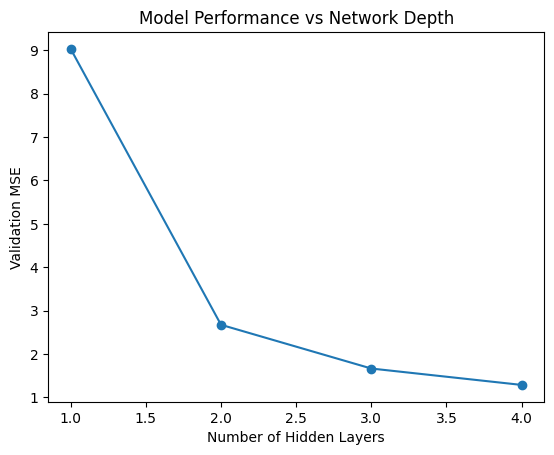

In [81]:
import time
import matplotlib.pyplot as plt

# ---------------------------------------
# Network Architectures (Depth Study)
# ---------------------------------------

# ---------------------------------------
# Network Architectures (Depth Study)
# ---------------------------------------

input_size = X_train.shape[1]
output_size = 1

depth_configs = {
    "depth1": [input_size, 64, output_size],
    "depth2": [input_size, 64, 64, output_size],
    "depth3": [input_size, 64, 64, 64, output_size],
    "depth4": [input_size, 64, 64, 64, 64, output_size]
}

experiment_results = {}

# ---------------------------------------
# Train Models for Each Depth
# ---------------------------------------

for label, structure in depth_configs.items():

    print("Running architecture:", label)

    act_list = ["relu"] * (len(structure) - 2) + ["linear"]

    net = MLP(
        layer_sizes=structure,
        activations=act_list,
        loss="mse",
        optimizer="adam",
        learning_rate=0.01,
        batch_size=64,
        weight_init="he"
    )

    np.random.seed(42)

    start_time = time.time()

    history = net.fit(X_train, y_train, X_val, y_val, epochs=100)

    total_time = time.time() - start_time
    avg_epoch_time = total_time / 100

    # ---------------------------------------
    # Plot Loss Curves
    # ---------------------------------------

    plt.figure()

    plt.plot(history["train_loss"], label="Train")
    plt.plot(history["val_loss"], label="Validation")

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Loss Curves ({label})")

    plt.legend()
    plt.show()

    # ---------------------------------------
    # Validation Performance
    # ---------------------------------------

    predictions, _ = net.forward(X_val)
    final_val_loss = net.loss_fn(y_val, predictions[-1])

    print("Validation MSE:", final_val_loss)
    print("Average Epoch Time:", avg_epoch_time)

    experiment_results[label] = {
        "loss": final_val_loss,
        "epoch_time": avg_epoch_time,
        "history": history
    }

# ---------------------------------------
# Summary Plot: Depth vs Performance
# ---------------------------------------

depth_values = [1, 2, 3, 4]

mse_scores = [
    experiment_results["depth1"]["loss"],
    experiment_results["depth2"]["loss"],
    experiment_results["depth3"]["loss"],
    experiment_results["depth4"]["loss"]
]

plt.figure()

plt.plot(depth_values, mse_scores, marker='o')

plt.xlabel("Number of Hidden Layers")
plt.ylabel("Validation MSE")
plt.title("Model Performance vs Network Depth")

plt.show()

Increasing network depth significantly improves model performance. The validation MSE decreases from 9.03 with one hidden layer to 1.29 with four hidden layers, indicating that deeper architectures can model more complex relationships in the dataset. However, deeper networks also increase the training time per epoch, showing a trade-off between accuracy and computational cost.

Hidden Width: 8
Total Parameters: 193
Validation MSE: 20.6226534172563
-------------------------------
Hidden Width: 16
Total Parameters: 513
Validation MSE: 11.043394196889501
-------------------------------
Hidden Width: 32
Total Parameters: 1537
Validation MSE: 4.043292837323644
-------------------------------
Hidden Width: 64
Total Parameters: 5121
Validation MSE: 3.107199604687672
-------------------------------
Hidden Width: 128
Total Parameters: 18433
Validation MSE: 1.2568744212101248
-------------------------------
Hidden Width: 256
Total Parameters: 69633
Validation MSE: 1.4915337259328645
-------------------------------


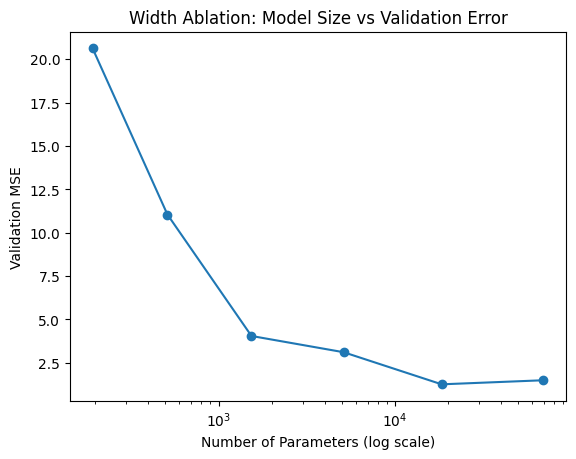

In [82]:
# ---------------------------------------
# Width Ablation Experiment
# ---------------------------------------

layer_widths = [8, 16, 32, 64, 128, 256]

param_list = []
mse_scores = []

for width in layer_widths:

    architecture = [input_size, width, width, output_size]

    act = ["relu", "relu", "linear"]

    model = MLP(
        layer_sizes=architecture,
        activations=act,
        loss="mse",
        optimizer="adam",
        learning_rate=0.01,
        batch_size=64,
        weight_init="he"
    )

    history = model.fit(X_train, y_train, X_val, y_val, epochs=100)

    # predictions on validation set
    predictions, _ = model.forward(X_val)

    validation_mse = model.loss_fn(y_val, predictions[-1])

    # ---------------------------------------
    # Parameter counting
    # ---------------------------------------

    total_params = 0
    for i in range(len(architecture) - 1):

        weight_params = architecture[i] * architecture[i+1]
        bias_params = architecture[i+1]

        total_params += weight_params + bias_params

    param_list.append(total_params)
    mse_scores.append(validation_mse)

    print("Hidden Width:", width)
    print("Total Parameters:", total_params)
    print("Validation MSE:", validation_mse)
    print("-------------------------------")


# ---------------------------------------
# Plot: Model Size vs Performance
# ---------------------------------------

plt.figure()

plt.plot(param_list, mse_scores, marker="o")

plt.xscale("log")

plt.xlabel("Number of Parameters (log scale)")
plt.ylabel("Validation MSE")
plt.title("Width Ablation: Model Size vs Validation Error")

plt.show()

Width vs Depth Performance Relationship

The depth and width ablation experiments show how increasing model capacity affects performance.

In the depth ablation experiment, increasing the number of hidden layers significantly improved performance. The validation MSE decreased from 9.03 with one hidden layer to 1.29 with four hidden layers, indicating that deeper networks are able to learn more complex hierarchical representations of the input features. However, increasing depth also increased the training time per epoch, as deeper networks require more computations.

In the width ablation experiment, increasing the number of neurons per layer also improved performance initially. The validation MSE decreased from 20.62 with width 8 to 1.26 with width 128, showing that wider networks have greater representational capacity. However, further increasing the width to 256 neurons slightly increased the error, suggesting diminishing returns and potential overfitting due to excessive parameters.

Overall, both increasing depth and width improve model performance, but they affect the network differently. Depth helps the model learn hierarchical feature representations, while width increases the number of features learned at each layer. In this experiment, moderate depth combined with sufficient width provided the best performance without excessive computational cost.


Training with activation: sigmoid
Gradient Mean: -1.4058053915793206e-05
Gradient Std: 0.00017546288492410059


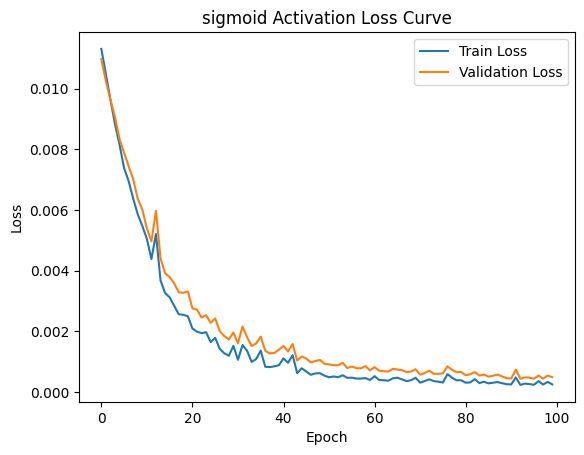

Layer 1 gradient magnitude: 9.095301721862145e-05
Layer 2 gradient magnitude: 5.5487792117147556e-05
Layer 3 gradient magnitude: 0.000847041849224223

Training with activation: tanh
Gradient Mean: -2.4986642681129377e-06
Gradient Std: 0.0005313329773431743


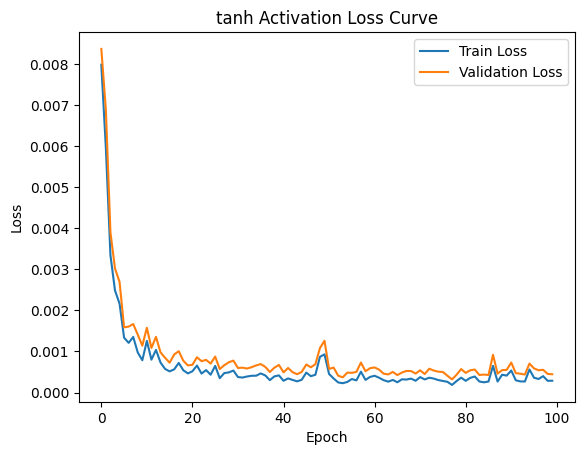

Layer 1 gradient magnitude: 6.744791504457861e-05
Layer 2 gradient magnitude: 4.6124780512925756e-05
Layer 3 gradient magnitude: 0.003930862873662561

Training with activation: relu
Gradient Mean: 1.166651825645454e-05
Gradient Std: 0.0006117457941070834


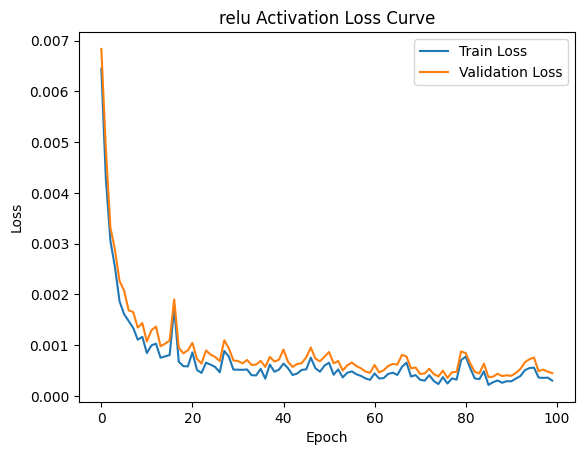

Dead neurons: 0
Layer 1 gradient magnitude: 0.000124849582620574
Layer 2 gradient magnitude: 5.834810204795135e-05
Layer 3 gradient magnitude: 0.0027377525607867378

Training with activation: leaky_relu
Gradient Mean: -1.0562532131696993e-05
Gradient Std: 0.00022727722880621078


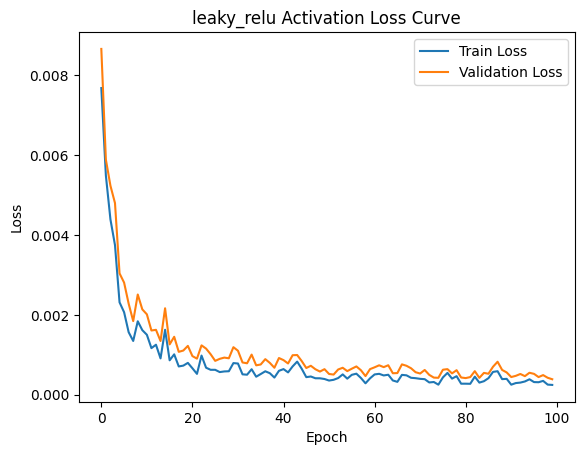

Dead neurons: 0
Layer 1 gradient magnitude: 0.00010223861491553482
Layer 2 gradient magnitude: 4.134552320044765e-05
Layer 3 gradient magnitude: 0.0012193099329395518


In [83]:
# ---------------------------------------------
# Activation Function Comparison
# ---------------------------------------------

architecture = [input_size, 64, 64, output_size]

activation_configs = {
    "sigmoid": ["sigmoid","sigmoid","sigmoid"],
    "tanh": ["tanh","tanh","sigmoid"],
    "relu": ["relu","relu","sigmoid"],
    "leaky_relu": ["leaky_relu","leaky_relu","sigmoid"]
}

activation_results = {}

# scale targets for sigmoid output
y_min = y_train.min()
y_max = y_train.max()

y_train_scaled = (y_train - y_min) / (y_max - y_min)
y_val_scaled = (y_val - y_min) / (y_max - y_min)

for name, act_list in activation_configs.items():

    print("\nTraining with activation:", name)

    model = MLP(
        layer_sizes=architecture,
        activations=act_list,
        loss="mse",
        optimizer="adam",
        learning_rate=0.01,
        batch_size=64,
        weight_init="he"
    )

    history = model.fit(X_train, y_train_scaled, X_val, y_val_scaled, epochs=100)

    activation_results[name] = {"history": history}

    # ---------------------------------------
    # Gradient statistics
    # ---------------------------------------

    grads_w, grads_b = model.backward(X_train, y_train_scaled)

    grad_vector = []

    for g in grads_w:
        grad_vector.append(g.flatten())

    grad_vector = np.concatenate(grad_vector)

    grad_mean = np.mean(grad_vector)
    grad_std = np.std(grad_vector)

    activation_results[name]["grad_mean"] = grad_mean
    activation_results[name]["grad_std"] = grad_std

    print("Gradient Mean:", grad_mean)
    print("Gradient Std:", grad_std)

    # ---------------------------------------
    # Loss curves
    # ---------------------------------------

    plt.figure()

    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")

    plt.title(f"{name} Activation Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()
    plt.show()

    # ---------------------------------------
    # Dead neuron analysis (ReLU)
    # ---------------------------------------

    activations, _ = model.forward(X_train)

    first_hidden = activations[1]

    if name in ["relu","leaky_relu"]:

        dead_units = np.sum(np.all(first_hidden <= 0, axis=0))

        print("Dead neurons:", dead_units)

    else:
        dead_units = 0

    activation_results[name]["dead_neurons"] = dead_units

    # ---------------------------------------
    # Gradient magnitude per layer
    # ---------------------------------------

    for i, g in enumerate(grads_w):

        magnitude = np.mean(np.abs(g))

        print("Layer", i+1, "gradient magnitude:", magnitude)

In [84]:
# -----------------------------------------
# Loss Function Comparison Experiment
# -----------------------------------------

loss_types = ["mse", "mae", "huber"]

loss_results = {}

# scale targets for sigmoid output
y_min = y_train.min()
y_max = y_train.max()

y_train_scaled = (y_train - y_min) / (y_max - y_min)
y_val_scaled = (y_val - y_min) / (y_max - y_min)

for loss_fn in loss_types:

    print("\nTraining model with loss:", loss_fn.upper())

    np.random.seed(42)

    net = MLP(
        layer_sizes=[input_size, 64, 64, output_size],
        activations=["relu", "relu", "sigmoid"],
        loss=loss_fn,
        optimizer="adam",
        learning_rate=0.001,
        batch_size=64,
        weight_init="he"
    )

    training_history = net.fit(
        X_train,
        y_train_scaled,
        X_val,
        y_val_scaled,
        epochs=30
    )

    # predictions on validation set
    predictions, _ = net.forward(X_val)

    validation_mse = np.mean((y_val_scaled - predictions[-1])**2)

    loss_results[loss_fn] = validation_mse

    print("Validation MSE:", validation_mse)

    # Optional: plot loss curves
    """
    plt.figure()
    plt.plot(training_history["train_loss"], label="Train")
    plt.plot(training_history["val_loss"], label="Validation")
    plt.title(f"{loss_fn.upper()} Training Curve")
    plt.legend()
    plt.show()
    """

# -----------------------------------------
# Final Loss Comparison
# -----------------------------------------

print("\nFinal Comparison (Validation MSE)")
for loss_fn in loss_types:
    print(loss_fn.upper(), ":", loss_results[loss_fn])


Training model with loss: MSE
Validation MSE: 0.001945156128875456

Training model with loss: MAE
Validation MSE: 0.00225118829640959

Training model with loss: HUBER
Validation MSE: 0.0020577643035449215

Final Comparison (Validation MSE)
MSE : 0.001945156128875456
MAE : 0.00225118829640959
HUBER : 0.0020577643035449215



Testing: sigmoid
Layer 1 Gradient Magnitude: 0.00018966068869012654
Layer 2 Gradient Magnitude: 0.00011620349603252629
Layer 3 Gradient Magnitude: 0.0025163856255920676

Testing: relu
Layer 1 Gradient Magnitude: 0.00026524040303673184
Layer 2 Gradient Magnitude: 0.0001361520976112572
Layer 3 Gradient Magnitude: 0.002746906907007576


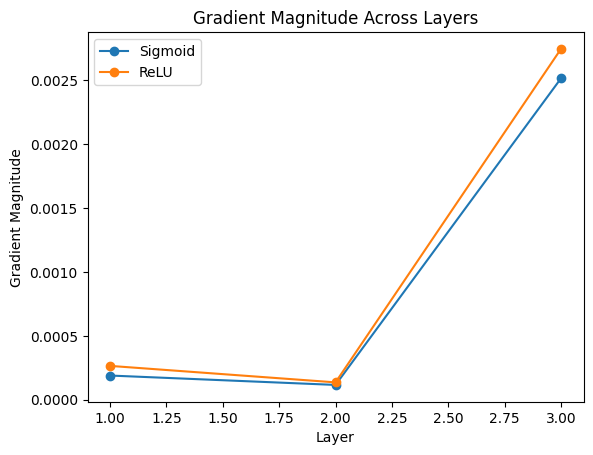

In [85]:
# -----------------------------------
# Vanishing Gradient Verification
# -----------------------------------

architecture = [input_size, 64, 64, output_size]

activation_tests = {
    "sigmoid": ["sigmoid","sigmoid","sigmoid"],
    "relu": ["relu","relu","sigmoid"]
}

grad_layer_results = {}

for name, acts in activation_tests.items():

    print("\nTesting:", name)

    model = MLP(
        layer_sizes=architecture,
        activations=acts,
        loss="mse",
        optimizer="adam",
        learning_rate=0.01,
        batch_size=64,
        weight_init="he"
    )

    history = model.fit(X_train, y_train_scaled, X_val, y_val_scaled, epochs=50)

    grads_w, grads_b = model.backward(X_train, y_train_scaled)

    layer_magnitudes = []

    for i, g in enumerate(grads_w):

        magnitude = np.mean(np.abs(g))
        layer_magnitudes.append(magnitude)

        print("Layer", i+1, "Gradient Magnitude:", magnitude)

    grad_layer_results[name] = layer_magnitudes


# -----------------------------------
# Plot Gradient Magnitudes
# -----------------------------------

layers = [1,2,3]

plt.figure()

plt.plot(layers, grad_layer_results["sigmoid"], marker='o', label="Sigmoid")
plt.plot(layers, grad_layer_results["relu"], marker='o', label="ReLU")

plt.xlabel("Layer")
plt.ylabel("Gradient Magnitude")
plt.title("Gradient Magnitude Across Layers")

plt.legend()
plt.show()

In [87]:
layer_sizes = [input_size,128,128,128,128,output_size]
activations = ["relu","relu","relu","relu","sigmoid"]

optimizers = [
    "sgd",
    "momentum",
    "adam",
    "nesterov",
    "adagrad",
    "rmsprop",
    "muon"
]

results = {}

for opt in optimizers:

    print("Training with:", opt)

    np.random.seed(42)

    model = MLP(
        layer_sizes=layer_sizes,
        activations=activations,
        loss="mse",
        learning_rate=0.0001,
        batch_size=64,
        optimizer=opt
    )

    history = model.fit(X_train, y_train_scaled, X_val, y_val_scaled, epochs=100)

    results[opt] = history

Training with: sgd
Training with: momentum
Training with: adam
Training with: nesterov
Training with: adagrad
Training with: rmsprop
Training with: muon


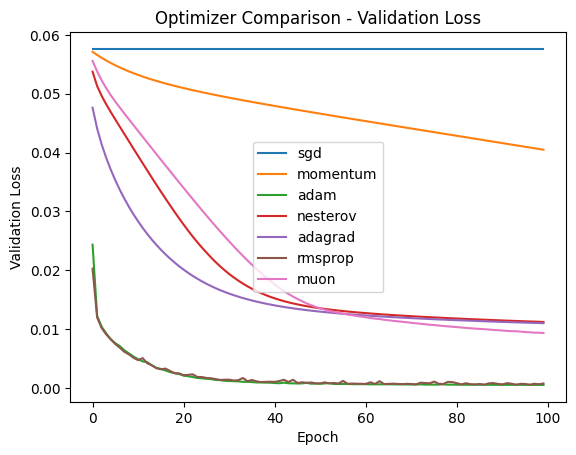

In [88]:
plt.figure()

for opt in results:
    plt.plot(results[opt]["val_loss"], label=opt)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Optimizer Comparison - Validation Loss")
plt.legend()
plt.show()

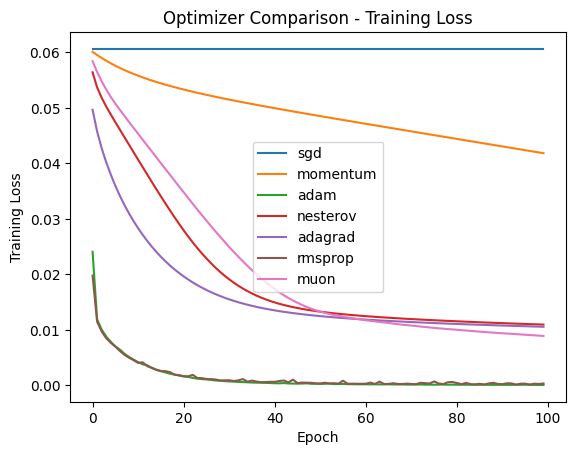

In [89]:
plt.figure()

for opt in results:
    plt.plot(results[opt]["train_loss"], label=opt)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Optimizer Comparison - Training Loss")
plt.legend()
plt.show()

In [90]:
def epoch_to_90(history):

    val_loss = history["val_loss"]

    best_loss = min(val_loss)

    threshold = best_loss * 1.1

    for epoch, loss in enumerate(val_loss):
        if loss <= threshold:
            return epoch

    return None

In [91]:
for opt in results:

    epoch90 = epoch_to_90(results[opt])

    print(opt, "reaches 90% performance at epoch:", epoch90)

sgd reaches 90% performance at epoch: 0
momentum reaches 90% performance at epoch: 67
adam reaches 90% performance at epoch: 73
nesterov reaches 90% performance at epoch: 67
adagrad reaches 90% performance at epoch: 65
rmsprop reaches 90% performance at epoch: 71
muon reaches 90% performance at epoch: 82


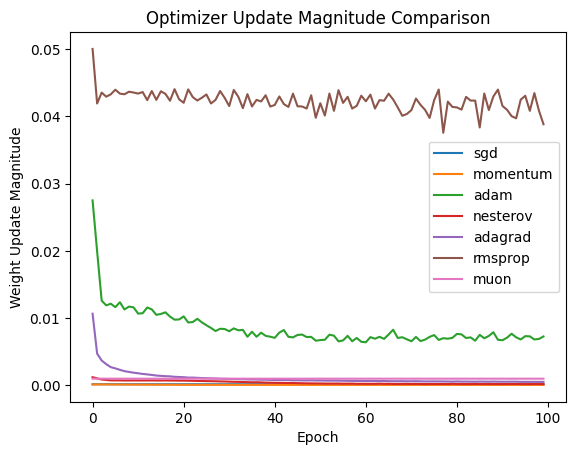

In [92]:
plt.figure()

for opt in results:
    plt.plot(results[opt]["update_mag"], label=opt)

plt.xlabel("Epoch")
plt.ylabel("Weight Update Magnitude")

plt.title("Optimizer Update Magnitude Comparison")

plt.legend()
plt.show()

In [93]:
learning_rates = [1e-4, 5e-4, 1e-3, 5e-3]

lr_results = {opt: [] for opt in optimizers}

for lr in learning_rates:

    for opt in optimizers:

        model = MLP(
            layer_sizes,
            activations,
            loss="mse",
            learning_rate=lr,
            batch_size=64,
            optimizer=opt
        )

        history = model.fit(X_train, y_train_scaled, X_val, y_val_scaled, epochs=50)

        final_loss = history["val_loss"][-1]

        lr_results[opt].append(final_loss)

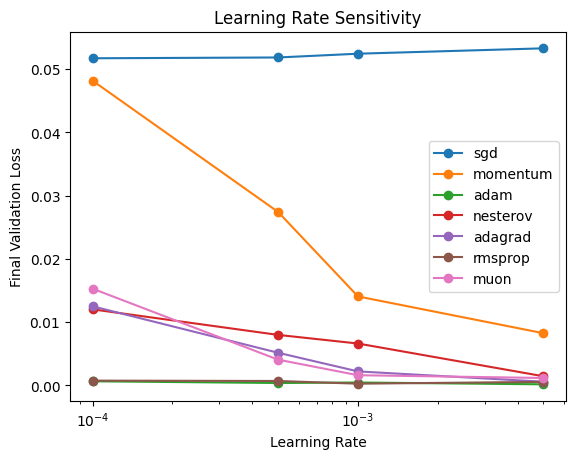

In [94]:
plt.figure()

for opt in lr_results:
    plt.plot(learning_rates, lr_results[opt], marker='o', label=opt)

plt.xscale("log")

plt.xlabel("Learning Rate")
plt.ylabel("Final Validation Loss")

plt.title("Learning Rate Sensitivity")

plt.legend()
plt.show()

In [95]:
lambdas = [0.001, 0.01, 0.1]

reg_configs = {
    "none": (None, 0),
    "l1_0.001": ("l1", 0.001),
    "l1_0.01": ("l1", 0.01),
    "l1_0.1": ("l1", 0.1),
    "l2_0.001": ("l2", 0.001),
    "l2_0.01": ("l2", 0.01),
    "l2_0.1": ("l2", 0.1)
}

reg_results = {}

for name, (reg_type, lam) in reg_configs.items():

    print("Training:", name)

    model = MLP(
        layer_sizes,
        activations,
        loss="mse",
        learning_rate=0.001,
        batch_size=64,
        optimizer="adam",
        regularization=reg_type,
        lambda_reg=lam
    )

    history = model.fit(X_train, y_train_scaled, X_val, y_val_scaled, epochs=100)

    reg_results[name] = history

Training: none
Training: l1_0.001
Training: l1_0.01
Training: l1_0.1
Training: l2_0.001
Training: l2_0.01
Training: l2_0.1


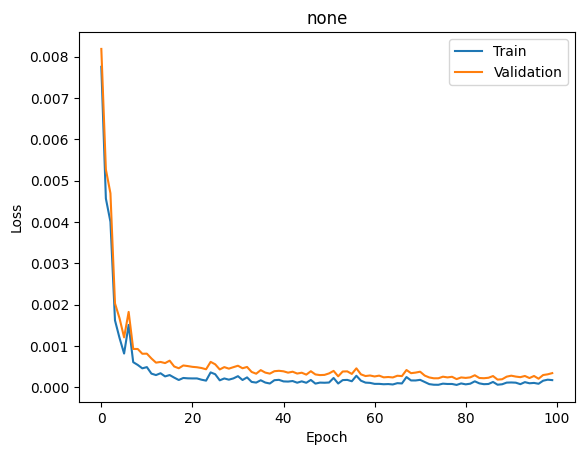

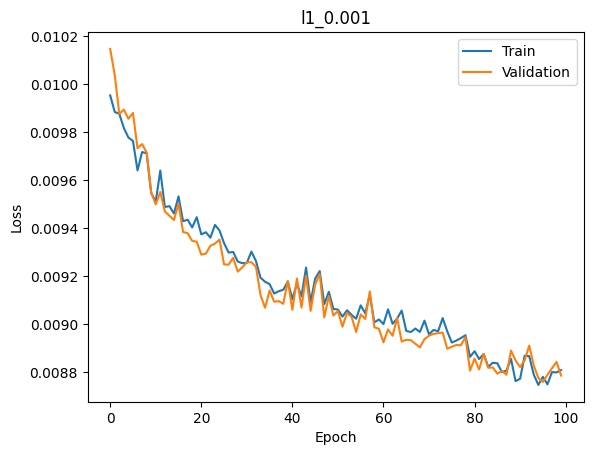

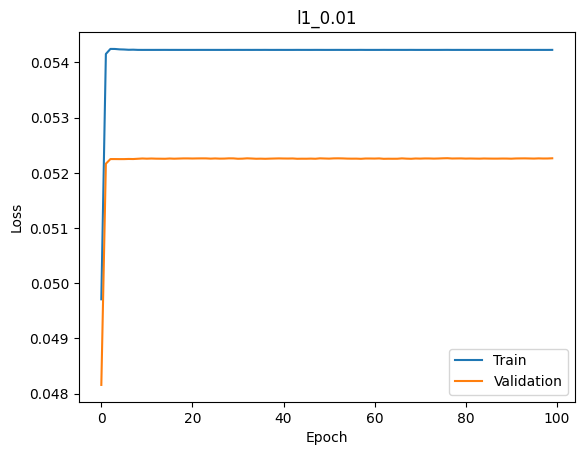

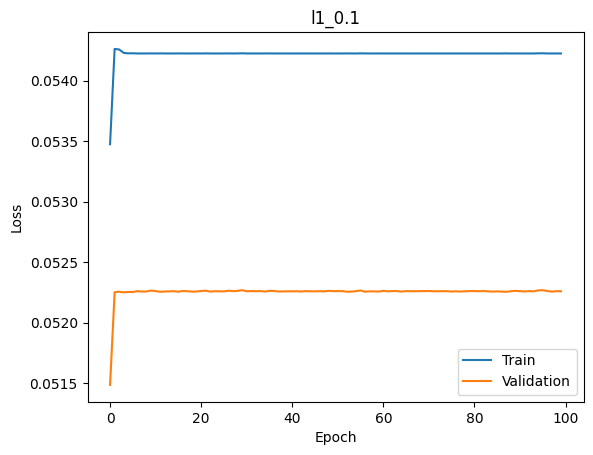

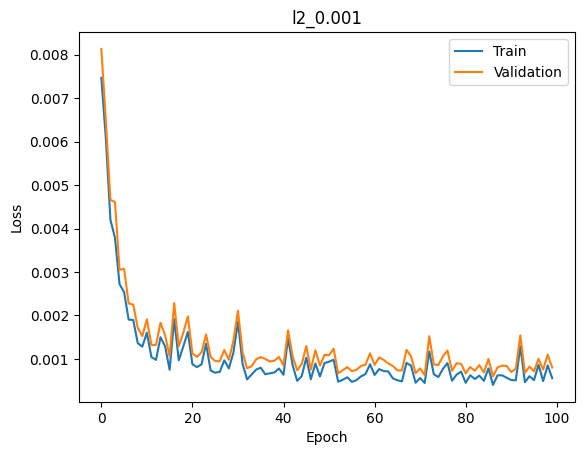

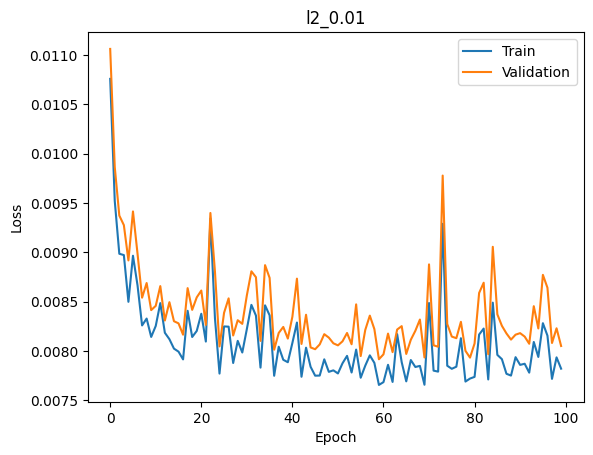

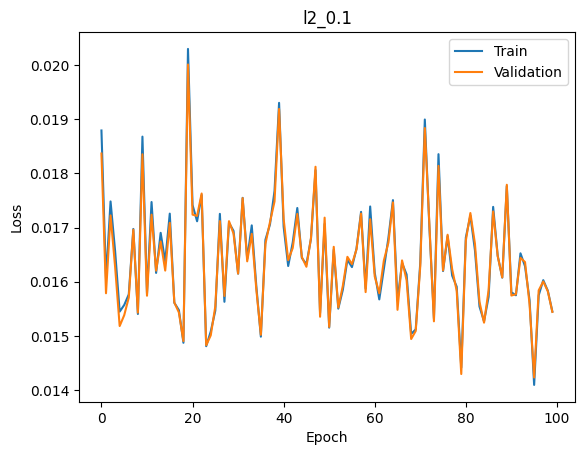

In [96]:
for name in reg_results:

    plt.figure()

    plt.plot(reg_results[name]["train_loss"], label="Train")
    plt.plot(reg_results[name]["val_loss"], label="Validation")

    plt.title(name)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()
    plt.show()

In [97]:
l1_sparsity = []

for lam in lambdas:

    model = MLP(
        layer_sizes,
        activations,
        loss="mse",
        learning_rate=0.001,
        batch_size=64,
        optimizer="adam",
        regularization="l1",
        lambda_reg=lam
    )

    model.fit(X_train, y_train_scaled, X_val, y_val_scaled, epochs=100)

    weights = np.concatenate([w.flatten() for w in model.weights])

    sparsity = np.mean(np.abs(weights) < 1e-3)

    l1_sparsity.append(sparsity)

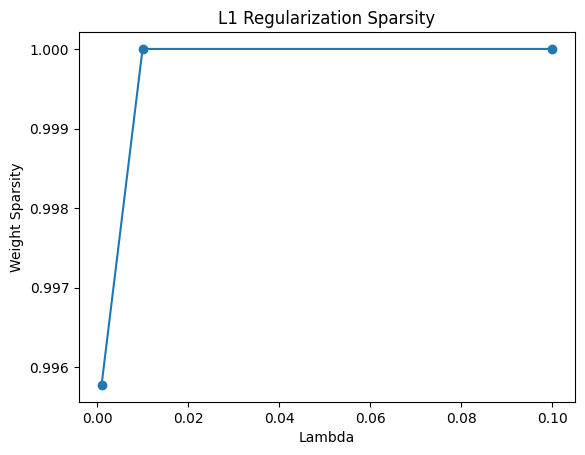

In [98]:
plt.figure()

plt.plot(lambdas, l1_sparsity, marker='o')

plt.xlabel("Lambda")
plt.ylabel("Weight Sparsity")

plt.title("L1 Regularization Sparsity")

plt.show()

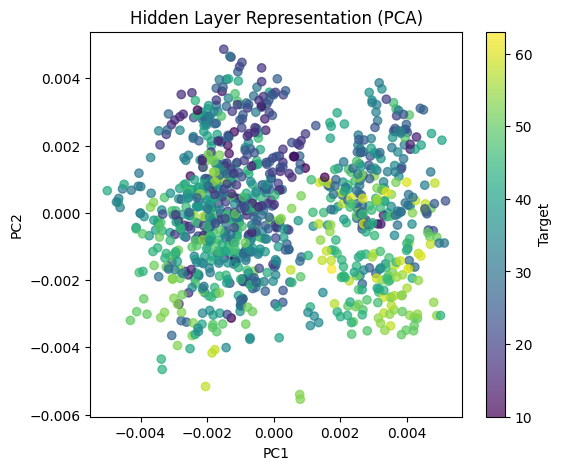

In [99]:
# Get hidden layer activations
activations, _ = model.forward(X_val)

hidden_features = activations[1]   # first hidden layer

# Center the data
X_centered = hidden_features - np.mean(hidden_features, axis=0)

# PCA using SVD
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# Take first 2 principal components
X_pca = X_centered @ Vt[:2].T

# Plot
plt.figure(figsize=(6,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_val,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hidden Layer Representation (PCA)")

plt.colorbar(label="Target")

plt.show()

In [101]:
# MLP prediction
mlp_pred, _ = model.forward(X_val)
mlp_mse = np.mean((y_val_scaled - mlp_pred[-1])**2)

# Adaline prediction
adaline_pred = adaline.predict(X_val)
adaline_mse = np.mean((y_val - adaline_pred)**2)

print("MLP Validation MSE:", mlp_mse)
print("Adaline Validation MSE:", adaline_mse)

MLP Validation MSE: 0.05225917463281064
Adaline Validation MSE: 1404.9585770793365


In [102]:
print("\nModel Comparison")

print("Model      | Validation MSE")
print("---------------------------")
print("Adaline    |", adaline_mse)
print("MLP        |", mlp_mse)


Model Comparison
Model      | Validation MSE
---------------------------
Adaline    | 1404.9585770793365
MLP        | 0.05225917463281064


7TH QUESTION


In [121]:
import sys
sys.path.append("/content")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from M_lp import MLP

Training finished.
Train feature size: (4000, 128)
Validation feature size: (1000, 128)
Running t-SNE...


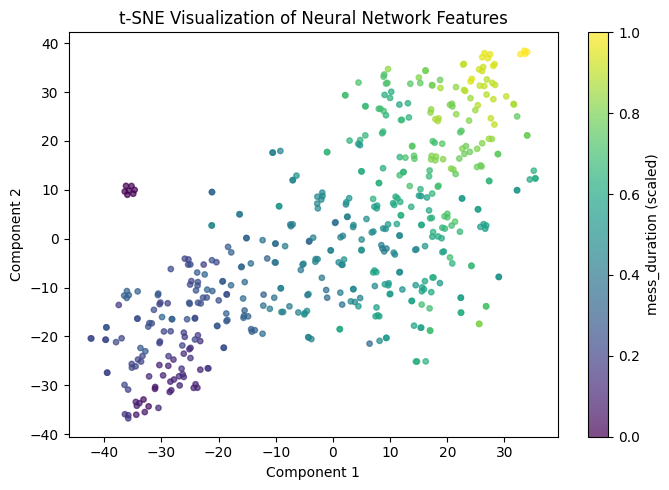

In [132]:
dataset = pd.read_csv("/content/iit_h_mess_dataset_5000.csv")

X = dataset.drop(columns=["student_id", "mess_duration"]).values
y = dataset["mess_duration"].values.reshape(-1,1)

# normalize features
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

np.random.seed(42)

perm = np.random.permutation(len(X))
split_index = int(0.8 * len(X))

X_train = X[perm[:split_index]]
X_val   = X[perm[split_index:]]

y_train = y[perm[:split_index]]
y_val   = y[perm[split_index:]]

# scale targets between 0 and 1
ymin = y_train.min()
ymax = y_train.max()

y_train_scaled = (y_train - ymin) / (ymax - ymin)
y_val_scaled   = (y_val - ymin) / (ymax - ymin)

input_dim = X.shape[1]

# =================================
# TRAIN THE BEST MLP MODEL
# =================================

np.random.seed(42)

best_model = MLP(
    layer_sizes=[input_dim,128,128,128,128,1],
    activations=["relu","relu","relu","relu","sigmoid"],
    loss="mse",
    learning_rate=0.001,
    batch_size=64,
    optimizer="adam"
)

best_model.fit(
    X_train,
    y_train_scaled,
    X_val,
    y_val_scaled,
    epochs=100
)

print("Training finished.")

# =================================
# NEURAL FEATURE EXTRACTION
# Penultimate layer representation
# =================================

def get_nn_features(X_data):
    activations, _ = best_model.forward(X_data)
    return activations[-2]

phi_train = get_nn_features(X_train)
phi_val   = get_nn_features(X_val)

print("Train feature size:", phi_train.shape)
print("Validation feature size:", phi_val.shape)

# =================================
# CUSTOM t-SNE IMPLEMENTATION
# =================================

def tsne_embedding(X, n_components=2, perplexity=30, iterations=300, lr=200, seed=42):

    np.random.seed(seed)
    n = X.shape[0]

    # compute pairwise distance matrix
    sq_norm = np.sum(X**2, axis=1)
    dist_matrix = sq_norm.reshape(-1,1) + sq_norm.reshape(1,-1) - 2*(X @ X.T)

    np.fill_diagonal(dist_matrix, 0)

    P = np.zeros((n,n))
    desired_entropy = np.log2(perplexity)

    # compute probability matrix
    for i in range(n):

        low, high = 0.0, 1e10
        sigma = 1.0

        distances = dist_matrix[i].copy()
        distances[i] = np.inf

        for _ in range(50):

            prob = np.exp(-distances/(2*sigma**2))
            prob[i] = 0

            prob_sum = prob.sum() + 1e-10
            prob = prob / prob_sum

            entropy = -np.sum(prob[prob>0]*np.log2(prob[prob>0]+1e-10))

            if entropy < desired_entropy:
                low = sigma
            else:
                high = sigma

            sigma = (low + high)/2 if high < 1e9 else sigma*2

        P[i] = prob

    # symmetrize probabilities
    P = (P + P.T)/(2*n)
    P = np.maximum(P,1e-12)

    # initialize low-dimensional map
    Y = np.random.randn(n,n_components)*0.01
    velocity = np.zeros_like(Y)
    gains = np.ones_like(Y)

    momentum = 0.5

    for step in range(1,iterations+1):

        sqY = np.sum(Y**2,axis=1)

        num = 1/(1 + sqY.reshape(-1,1) + sqY.reshape(1,-1) - 2*(Y @ Y.T))
        np.fill_diagonal(num,0)

        Q = num/(num.sum()+1e-10)
        Q = np.maximum(Q,1e-12)

        diff = P - Q

        grad = np.zeros_like(Y)

        for i in range(n):
            grad[i] = 4*np.sum(((diff[:,i]*num[:,i]).reshape(-1,1))*(Y[i]-Y),axis=0)

        if step == 100:
            momentum = 0.8

        gains = (gains+0.2)*((grad>0)!=(velocity>0)) + (gains*0.8)*((grad>0)==(velocity>0))
        gains = np.maximum(gains,0.01)

        velocity = momentum*velocity - lr*gains*grad
        Y = Y + velocity

        Y = Y - Y.mean(axis=0)

    return Y

# =================================
# RUN t-SNE ON A SUBSET
# =================================

print("Running t-SNE...")

subset_features = phi_train[:500]

embedding = tsne_embedding(subset_features, iterations=300)

# =================================
# VISUALIZE RESULTS
# =================================

plt.figure(figsize=(7,5))

points = plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=y_train_scaled[:500].flatten(),
    cmap="viridis",
    alpha=0.7,
    s=15
)

plt.colorbar(points,label="mess_duration (scaled)")

plt.title("t-SNE Visualization of Neural Network Features")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.tight_layout()
plt.show()

Linear Kernel Test MSE: 29.8182


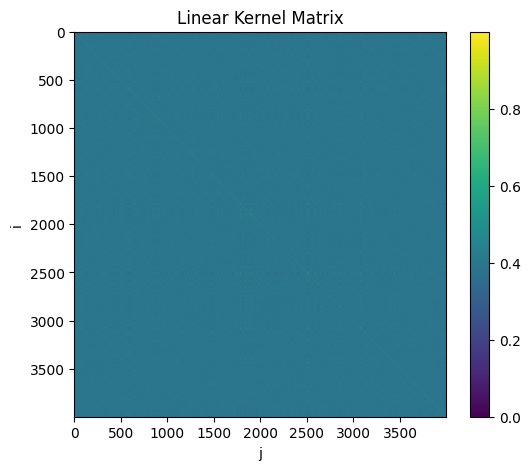

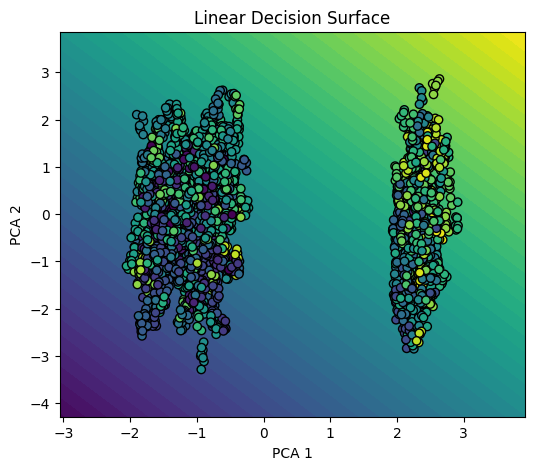

Polynomial Kernel (d=2) Test MSE: 24.0908


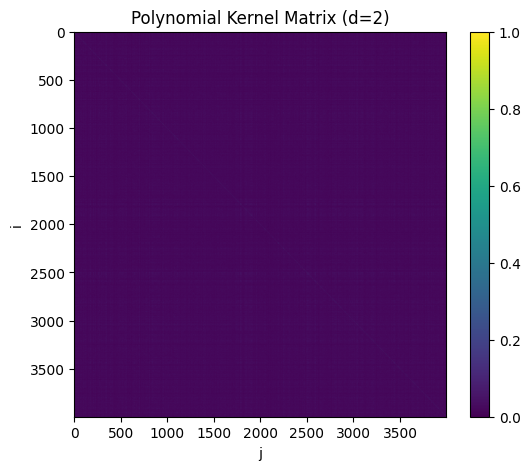

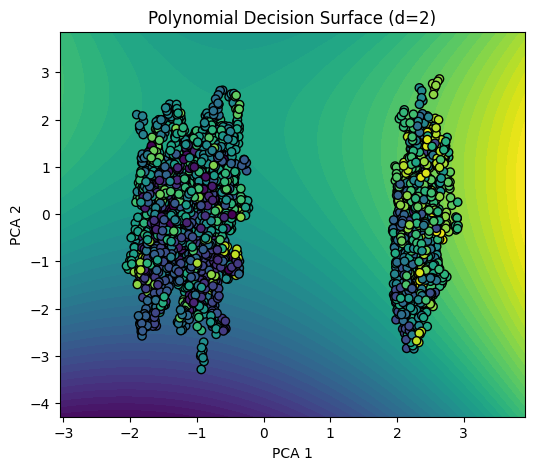

Polynomial Kernel (d=3) Test MSE: 14.2797


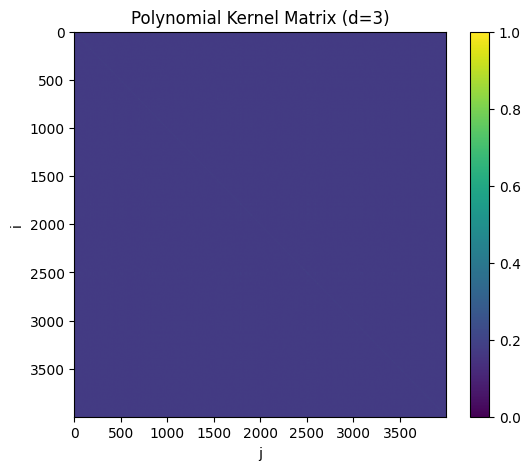

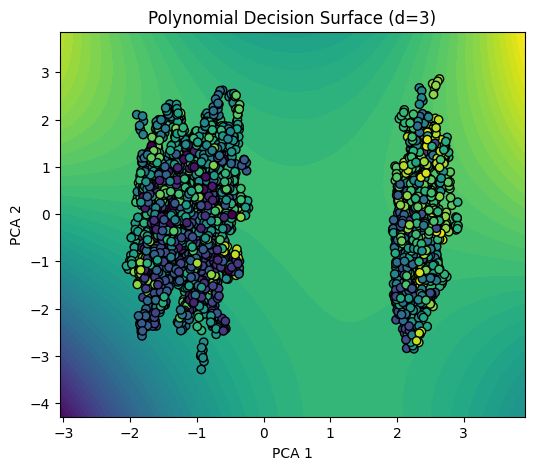

RBF Kernel (gamma=0.01) Test MSE: 22.9103


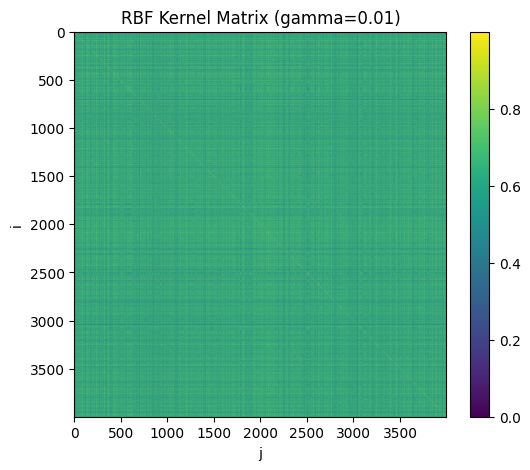

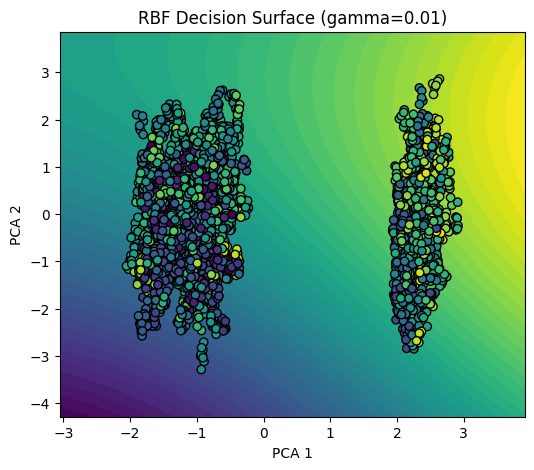

RBF Kernel (gamma=0.1) Test MSE: 15.1126


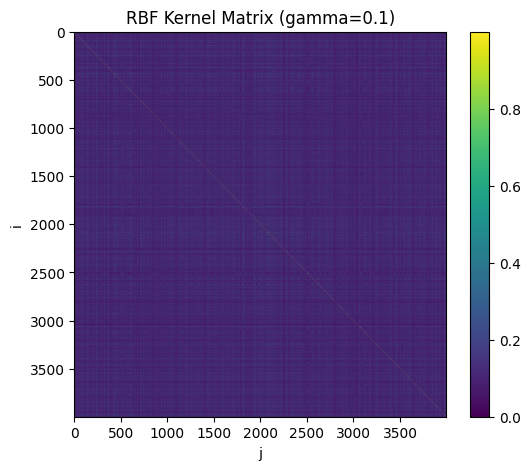

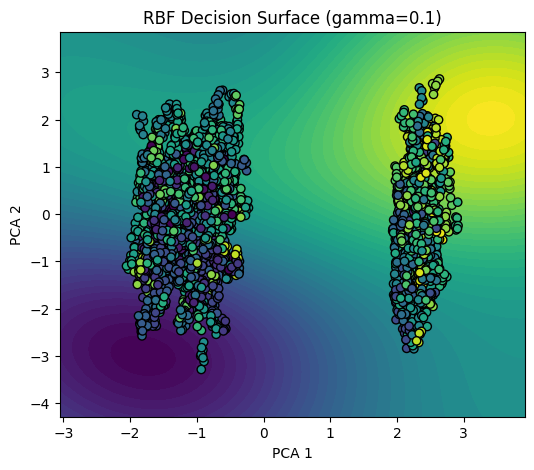

RBF Kernel (gamma=1.0) Test MSE: 28.0568


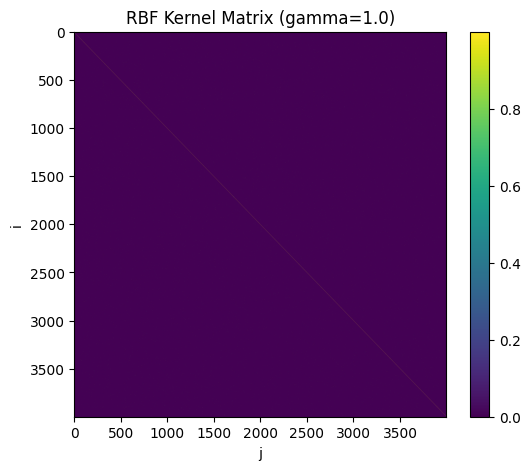

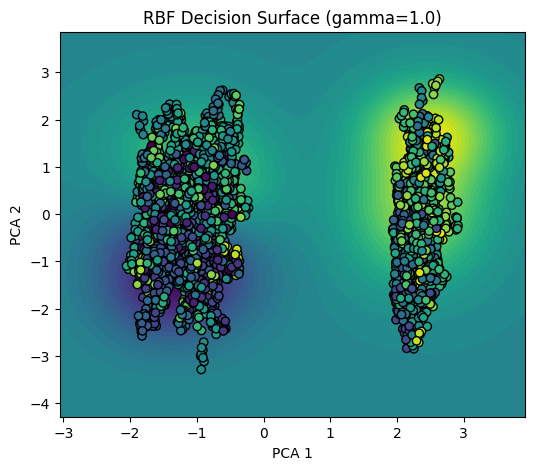

Neural Kernel Test MSE: 6.2826


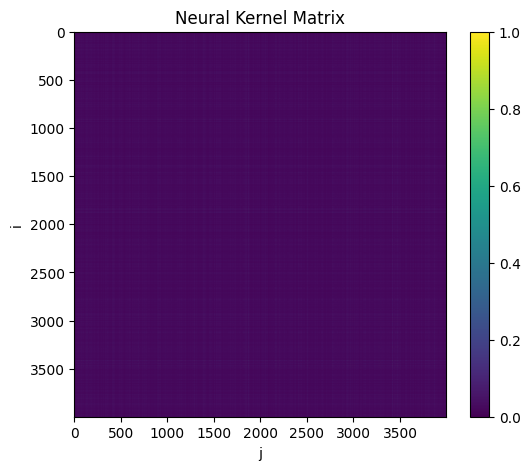


Kernel Comparison Results
Linear : 29.8182
Poly_d2 : 24.0908
Poly_d3 : 14.2797
RBF_gamma0.01 : 22.9103
RBF_gamma0.1 : 15.1126
RBF_gamma1.0 : 28.0568
Neural : 6.2826


In [133]:
# ============================================
# 7.2.2 KERNEL COMPARISON
# ============================================

from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA

# ============================================
# Kernel Functions
# ============================================

def linear_kernel_matrix(XA, XB):
    return XA @ XB.T


def polynomial_kernel_matrix(XA, XB, degree=2, c=1):
    return (XA @ XB.T + c) ** degree


def rbf_kernel_matrix(XA, XB, gamma=0.1):

    XA_sq = np.sum(XA**2, axis=1).reshape(-1,1)
    XB_sq = np.sum(XB**2, axis=1).reshape(1,-1)

    dist = XA_sq + XB_sq - 2*(XA @ XB.T)

    return np.exp(-gamma * dist)


def neural_kernel_matrix(PhiA, PhiB):
    return PhiA @ PhiB.T


# ============================================
# Kernel Matrix Visualization
# ============================================

def plot_kernel_matrix(K, title):

    K_norm = (K - K.min()) / (K.max() - K.min() + 1e-8)

    plt.figure(figsize=(6,5))
    plt.imshow(K_norm, cmap="viridis", aspect="auto")
    plt.colorbar()
    plt.title(title)
    plt.xlabel("j")
    plt.ylabel("i")
    plt.show()


# ============================================
# Decision Surface Visualization
# ============================================

def plot_decision_surface(X, y, X_train, model, kernel_func, name):

    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    x_min, x_max = X_2d[:,0].min()-1, X_2d[:,0].max()+1
    y_min, y_max = X_2d[:,1].min()-1, X_2d[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 80),
        np.linspace(y_min, y_max, 80)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_original = pca.inverse_transform(grid)

    K_grid = kernel_func(grid_original, X_train)

    Z = model.predict(K_grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))

    plt.contourf(xx, yy, Z, levels=50)

    plt.scatter(
        X_2d[:,0],
        X_2d[:,1],
        c=y.flatten(),
        edgecolors="k"
    )

    plt.title(name)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()


# ============================================
# Train + Evaluate SVR
# ============================================

def train_evaluate_kernel(K_train, K_val, y_train_scaled, y_val, name):

    svr = SVR(kernel="precomputed", C=1.0, epsilon=0.1)

    svr.fit(K_train, y_train_scaled.ravel())

    y_pred_scaled = svr.predict(K_val)

    # convert predictions back to original scale
    y_pred = y_pred_scaled * (ymax - ymin) + ymin

    mse = mean_squared_error(y_val, y_pred)

    print(f"{name} Test MSE: {mse:.4f}")

    return mse, svr


results = {}
models = {}

# ============================================
# Linear Kernel
# ============================================

K_train = linear_kernel_matrix(X_train, X_train)
K_val   = linear_kernel_matrix(X_val, X_train)

mse, model = train_evaluate_kernel(
    K_train,
    K_val,
    y_train_scaled,
    y_val,
    "Linear Kernel"
)

results["Linear"] = mse
models["Linear"] = model

plot_kernel_matrix(K_train, "Linear Kernel Matrix")

plot_decision_surface(
    X_train,
    y_train,
    X_train,
    model,
    linear_kernel_matrix,
    "Linear Decision Surface"
)


# ============================================
# Polynomial Kernel
# ============================================

for d in [2,3]:

    kernel = lambda A,B: polynomial_kernel_matrix(A,B,degree=d)

    K_train = kernel(X_train, X_train)
    K_val   = kernel(X_val, X_train)

    mse, model = train_evaluate_kernel(
        K_train,
        K_val,
        y_train_scaled,
        y_val,
        f"Polynomial Kernel (d={d})"
    )

    results[f"Poly_d{d}"] = mse
    models[f"Poly_d{d}"] = model

    plot_kernel_matrix(K_train, f"Polynomial Kernel Matrix (d={d})")

    plot_decision_surface(
        X_train,
        y_train,
        X_train,
        model,
        kernel,
        f"Polynomial Decision Surface (d={d})"
    )


# ============================================
# RBF Kernel
# ============================================

for gamma in [0.01, 0.1, 1.0]:

    kernel = lambda A,B: rbf_kernel_matrix(A,B,gamma=gamma)

    K_train = kernel(X_train, X_train)
    K_val   = kernel(X_val, X_train)

    mse, model = train_evaluate_kernel(
        K_train,
        K_val,
        y_train_scaled,
        y_val,
        f"RBF Kernel (gamma={gamma})"
    )

    results[f"RBF_gamma{gamma}"] = mse
    models[f"RBF_gamma{gamma}"] = model

    plot_kernel_matrix(K_train, f"RBF Kernel Matrix (gamma={gamma})")

    plot_decision_surface(
        X_train,
        y_train,
        X_train,
        model,
        kernel,
        f"RBF Decision Surface (gamma={gamma})"
    )


# ============================================
# Neural Kernel
# ============================================

K_train = neural_kernel_matrix(phi_train, phi_train)
K_val   = neural_kernel_matrix(phi_val, phi_train)

mse, model = train_evaluate_kernel(
    K_train,
    K_val,
    y_train_scaled,
    y_val,
    "Neural Kernel"
)

results["Neural"] = mse
models["Neural"] = model

plot_kernel_matrix(K_train, "Neural Kernel Matrix")


# ============================================
# Final Comparison
# ============================================

print("\nKernel Comparison Results")

for k,v in results.items():
    print(f"{k} : {v:.4f}")